# Random Forest All-Data Experimental Investigation

This notebook is for exploratory investigation on the full merged dataset. It fits the frozen Optuna-selected Random Forest on all available rows and examines how ranking quality and error behave across experimental conditions.

Because the model is fit and evaluated on the same full dataset here, these results are for diagnosis and dataset understanding, not for unbiased generalization claims.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

project_root = Path.cwd().resolve()
while not (project_root / "utils").exists() and project_root != project_root.parent:
    project_root = project_root.parent

if not (project_root / "utils").exists():
    raise RuntimeError("Could not locate project root containing the utils package")

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from classical_ml.random_forest import (
    RandomForestDataBuilder,
    RandomForestExperimentConfig,
    RandomForestTrainer,
    compute_regression_metrics,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## Frozen Configuration

In [2]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")

assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"
assert historic_path, "CMSIRNA_RAW_HISTORIC_DATA_PATH is not set"

config = RandomForestExperimentConfig(
    target_column="Inhibition",
    strict_cleaning=True,
    add_mrna=True,
    use_normalized_conditions=False,
    random_state=42,
    n_estimators=500,
    max_depth=None,
    min_samples_split=7,
    min_samples_leaf=1,
    max_features=0.3,
    n_jobs=-1,
)

config

RandomForestExperimentConfig(target_column='Inhibition', target_len=25, strict_cleaning=True, add_mrna=True, fetch_missing_mrna=True, use_normalized_conditions=False, n_splits=3, leak_n=30, outer_test_size=0.33, random_state=42, n_estimators=500, max_depth=None, min_samples_split=7, min_samples_leaf=1, max_features=0.3, n_jobs=-1, tuning_n_iter=20, tuning_scoring='neg_mean_absolute_error', optuna_n_trials=20)

## Build Data

In [3]:
builder = RandomForestDataBuilder(config)
prepared = builder.build_from_merged_sources(cmsirna_path, historic_path)

print("Enriched dataframe shape:", prepared.enriched_df.shape)
print("Feature matrix shape:", prepared.X.shape)
print("Target shape:", prepared.y.shape)
print("Unique genes:", len(np.unique(prepared.groups)))

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

## Fit Frozen Model On All Data

In [4]:
trainer = RandomForestTrainer(config)
trainer.fit(prepared.X, prepared.y)
y_pred_all = trainer.predict(prepared.X)

all_predictions = prepared.enriched_df.reset_index().rename(columns={"index": "source_index"}).copy()
all_predictions["group"] = prepared.groups
all_predictions["y_true"] = prepared.y
all_predictions["y_pred"] = y_pred_all
all_predictions["residual"] = all_predictions["y_true"] - all_predictions["y_pred"]
all_predictions["abs_error"] = all_predictions["residual"].abs()
all_predictions["patent_group"] = all_predictions.get("patent_ID", pd.Series(index=all_predictions.index, dtype=object)).fillna("HISTORIC_OR_UNKNOWN")
all_predictions["Authorization_status"] = all_predictions.get("Authorization_status", pd.Series(index=all_predictions.index, dtype=object)).fillna("UNKNOWN")
all_predictions["Title"] = all_predictions.get("Title", pd.Series(index=all_predictions.index, dtype=object)).fillna("HISTORIC_OR_UNKNOWN")

all_data_metrics = pd.DataFrame([compute_regression_metrics(all_predictions["y_true"], all_predictions["y_pred"])])
all_data_metrics

,pearson,spearman,rmse,mae
0,0.952201,0.955978,11.474675,8.419739


## Spearman By Experimental Slice

In [26]:
def grouped_spearman(df, group_cols, min_samples=10):
    rows = []
    for keys, group_df in df.groupby(group_cols, dropna=False):
        if len(group_df) < min_samples:
            continue
        corr = spearmanr(group_df["y_true"], group_df["y_pred"], nan_policy="omit").statistic
        if pd.isna(corr):
            continue
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: value for col, value in zip(group_cols, keys)}
        row.update({
            "n_samples": len(group_df),
            "spearman": float(corr),
            "mae": float(group_df["abs_error"].mean()),
            "mean_true": float(group_df["y_true"].mean()),
            "mean_pred": float(group_df["y_pred"].mean()),
        })
        rows.append(row)
    return pd.DataFrame(rows).sort_values(["spearman", "mae"], ascending=[True, False]).reset_index(drop=True)

spearman_by_concentration = grouped_spearman(all_predictions, ["Concentration_nM"], min_samples=20)
spearman_by_concentration_gene = grouped_spearman(all_predictions, ["Concentration_nM", "group"], min_samples=10)
spearman_by_concentration_patent = grouped_spearman(all_predictions, ["Concentration_nM", "patent_group"], min_samples=10)

spearman_by_concentration

,Concentration_nM,n_samples,spearman,mae,mean_true,mean_pred
0,0.60000,35,0.393868,7.810858,50.999143,50.854742
1,3.00000,35,0.639757,7.089560,71.316857,70.969218
2,150.00000,90,0.644317,16.050638,36.578333,37.289894
3,15.00000,35,0.725547,3.828794,86.038000,85.396934
4,0.00064,114,0.737387,4.733372,-1.481053,0.390391
5,0.00030,40,0.772941,4.084943,5.699000,7.291322
6,25.00000,22,0.780915,5.995606,78.078182,72.117748
7,0.00300,65,0.786105,5.949407,3.734462,5.474791
8,0.02000,41,0.826778,9.301775,-7.256098,-8.063237
9,0.00320,114,0.846884,5.165192,1.716491,2.687383


In [27]:
spearman_by_concentration_gene.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,group,n_samples,spearman,mae,mean_true,mean_pred
0,0.60000,HSD17B13,35,0.393868,7.810858,50.999143,50.854742
1,50.00000,AGT,21,0.578298,5.487515,83.792857,79.593560
2,0.00064,HSD17B13,13,0.633333,7.371886,11.537692,12.036833
3,3.00000,HSD17B13,35,0.639757,7.089560,71.316857,70.969218
4,150.00000,HSD17B13,90,0.644317,16.050638,36.578333,37.289894
5,0.00064,AGT,101,0.706009,4.393761,-3.156733,-1.108656
6,0.00030,HSD17B13,21,0.715400,4.209725,4.458095,8.371505
7,15.00000,HSD17B13,35,0.725547,3.828794,86.038000,85.396934
8,0.00300,AGT,20,0.744820,6.863495,3.252000,5.376793
9,0.40000,HSD17B13,13,0.761111,3.758071,84.767692,81.009621


In [28]:
spearman_by_concentration_patent.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,patent_group,n_samples,spearman,mae,mean_true,mean_pred
0,0.10000,CN112313335A,184,0.072250,9.357299,98.657065,89.300736
1,0.60000,WO2023091644A2,35,0.393868,7.810858,50.999143,50.854742
2,1.00000,CN116940681A,21,0.474830,7.263696,88.250476,86.832767
3,10.00000,CN112313335A,182,0.537957,5.474014,92.877308,87.781537
4,50.00000,CN116732034A,21,0.578298,5.487515,83.792857,79.593560
5,5.00000,WO2023091644A2,43,0.582017,8.391146,22.656279,25.578575
6,3.00000,WO2023091644A2,35,0.639757,7.089560,71.316857,70.969218
7,150.00000,WO2023091644A2,90,0.644317,16.050638,36.578333,37.289894
8,50.00000,WO2023091644A2,133,0.665322,14.496560,43.357594,42.119503
9,0.00064,WO2023088427A1,77,0.671459,4.282206,-2.248442,-0.867958


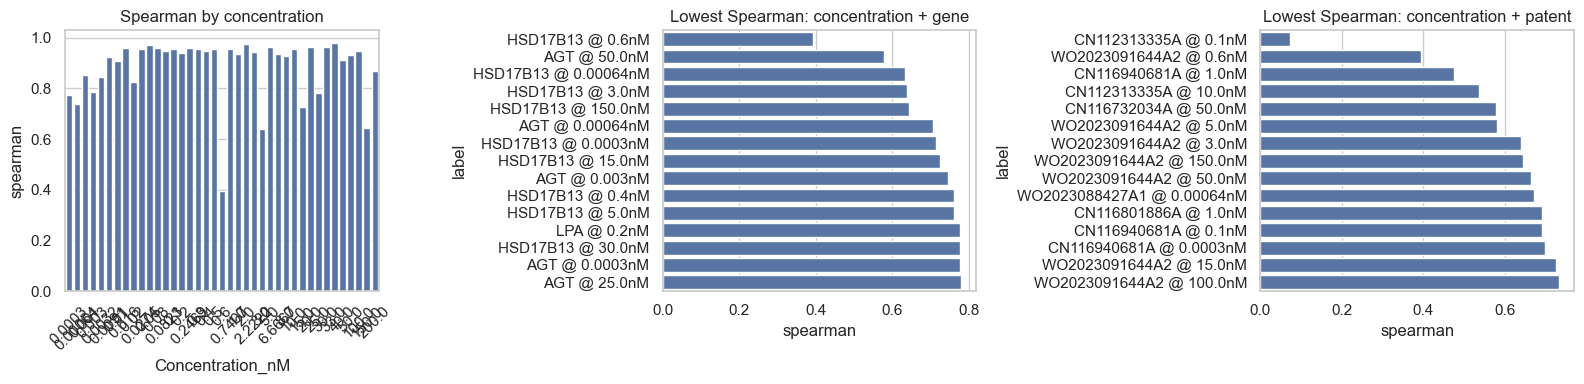

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=spearman_by_concentration.sort_values("Concentration_nM"), x="Concentration_nM", y="spearman", ax=axes[0])
axes[0].set_title("Spearman by concentration")
axes[0].tick_params(axis="x", rotation=45)

top_bad_gene = spearman_by_concentration_gene.head(min(15, len(spearman_by_concentration_gene))).copy()
top_bad_gene["label"] = top_bad_gene["group"] + " @ " + top_bad_gene["Concentration_nM"].astype(str) + "nM"
sns.barplot(data=top_bad_gene, x="spearman", y="label", ax=axes[1])
axes[1].set_title("Lowest Spearman: concentration + gene")

top_bad_patent = spearman_by_concentration_patent.head(min(15, len(spearman_by_concentration_patent))).copy()
top_bad_patent["label"] = top_bad_patent["patent_group"].astype(str).str.slice(0, 18) + " @ " + top_bad_patent["Concentration_nM"].astype(str) + "nM"
sns.barplot(data=top_bad_patent, x="spearman", y="label", ax=axes[2])
axes[2].set_title("Lowest Spearman: concentration + patent")

plt.tight_layout()

## Experimental Features Defining Issues

In [30]:
def issue_summary(df, group_col, min_samples=20):
    rows = []
    for value, group_df in df.groupby(group_col, dropna=False):
        if len(group_df) < min_samples:
            continue
        corr = spearmanr(group_df["y_true"], group_df["y_pred"], nan_policy="omit").statistic
        rows.append({
            group_col: value,
            "n_samples": len(group_df),
            "mae": float(group_df["abs_error"].mean()),
            "rmse": float(np.sqrt(np.mean(np.square(group_df["residual"])))),
            "spearman": float(corr) if not pd.isna(corr) else np.nan,
            "mean_true": float(group_df["y_true"].mean()),
            "mean_pred": float(group_df["y_pred"].mean()),
        })
    return pd.DataFrame(rows).sort_values(["spearman", "mae"], ascending=[True, False]).reset_index(drop=True)

issue_by_cell_type = issue_summary(all_predictions, "Cell_Type", min_samples=30)
issue_by_concentration = issue_summary(all_predictions, "Concentration_nM", min_samples=20)
issue_by_time = issue_summary(all_predictions, "Time_of_administration_h", min_samples=20)
issue_by_patent = issue_summary(all_predictions, "patent_group", min_samples=20)
issue_by_authorization = issue_summary(all_predictions, "Authorization_status", min_samples=20)

issue_by_cell_type.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Cell_Type,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,Primary human hepatocytes,3015,11.025303,15.802755,0.853957,50.586438,51.078402
1,Human iPSC-derived cortical neurons,314,9.928550,13.276049,0.923792,49.032803,48.936747
2,Non-human hepatocytes,206,6.620691,8.833698,0.933779,20.802767,21.690618
3,HepG2,1651,8.431750,11.634180,0.934249,40.566778,40.713785
4,Primary Cynomolgus Monkey Hepatocytes,4445,8.995342,12.099164,0.939606,33.751663,33.714658
5,HEK293 Cells,262,9.875843,12.641261,0.943237,64.443051,64.752062
6,H1299 Cells,2394,6.345005,8.022502,0.943720,68.737594,68.552322
7,T24 Cells,76,9.322510,11.324102,0.951551,33.131579,35.247071
8,COS7,3888,6.570450,8.642212,0.955200,24.806379,24.756470
9,Huh7,1602,7.149113,9.838373,0.961689,40.851504,40.835193


In [31]:
issue_by_concentration.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,0.60000,35,7.810858,10.000055,0.393868,50.999143,50.854742
1,3.00000,35,7.089560,8.611057,0.639757,71.316857,70.969218
2,150.00000,90,16.050638,19.152273,0.644317,36.578333,37.289894
3,15.00000,35,3.828794,5.734543,0.725547,86.038000,85.396934
4,0.00064,114,4.733372,5.931613,0.737387,-1.481053,0.390391
5,0.00030,40,4.084943,5.277078,0.772941,5.699000,7.291322
6,25.00000,22,5.995606,7.136728,0.780915,78.078182,72.117748
7,0.00300,65,5.949407,8.033820,0.786105,3.734462,5.474791
8,0.02000,41,9.301775,11.613841,0.826778,-7.256098,-8.063237
9,0.00320,114,5.165192,6.672300,0.846884,1.716491,2.687383


In [32]:
issue_by_time.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Time_of_administration_h,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,40.0,199,6.666654,8.749821,0.911996,27.202010,27.712109
1,168.0,314,9.928550,13.276049,0.923792,49.032803,48.936747
2,4.0,76,9.322510,11.324102,0.951551,33.131579,35.247071
3,48.0,9555,7.385938,9.792670,0.952697,50.236203,50.002582
4,24.0,25415,8.963993,12.227438,0.955175,41.344910,41.307822
5,72.0,1406,5.469706,7.090944,0.965909,16.122731,16.136773


In [33]:
issue_by_patent.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,patent_group,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,CN112313335A,366,7.426266,10.936156,0.364085,95.782978,88.545287
1,CN116732034A,30,6.370733,7.835293,0.414553,83.838000,78.369019
2,CN113980966A,57,4.306662,6.646008,0.770736,83.438596,83.148377
3,CN116801886A,272,10.682151,14.137792,0.833610,50.522426,51.761515
4,CN117448322A,132,15.311700,21.524332,0.838283,45.159848,45.767979
5,WO2022121959A1,100,16.999135,21.428911,0.853374,64.982500,61.006146
6,CN109957567B,45,11.130420,13.652251,0.860799,59.400000,59.572685
7,WO2023213284A1,48,3.968672,6.210650,0.880571,86.482083,85.501375
8,WO2022089486A1,298,4.859508,6.857039,0.893895,78.144295,75.906789
9,WO2022256395A1,2067,8.618500,12.232176,0.908537,36.786589,36.576125


In [34]:
issue_by_authorization.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Authorization_status,n_samples,mae,rmse,spearman,mean_true,mean_pred
0,Published,227,6.117385,8.247127,0.908683,25.141850,25.802873
1,Unknown Status,13487,8.264261,11.437463,0.946745,33.306871,33.942267
2,UNKNOWN,3515,6.765299,8.610559,0.949477,64.834626,64.735357
3,Substantive Examination,16772,8.841440,12.117254,0.951729,46.031340,45.362607
4,Withdrawn,1155,9.170060,11.186875,0.960620,29.797056,30.565491
5,Granted,1809,8.693672,11.018254,0.968960,48.380293,47.846725


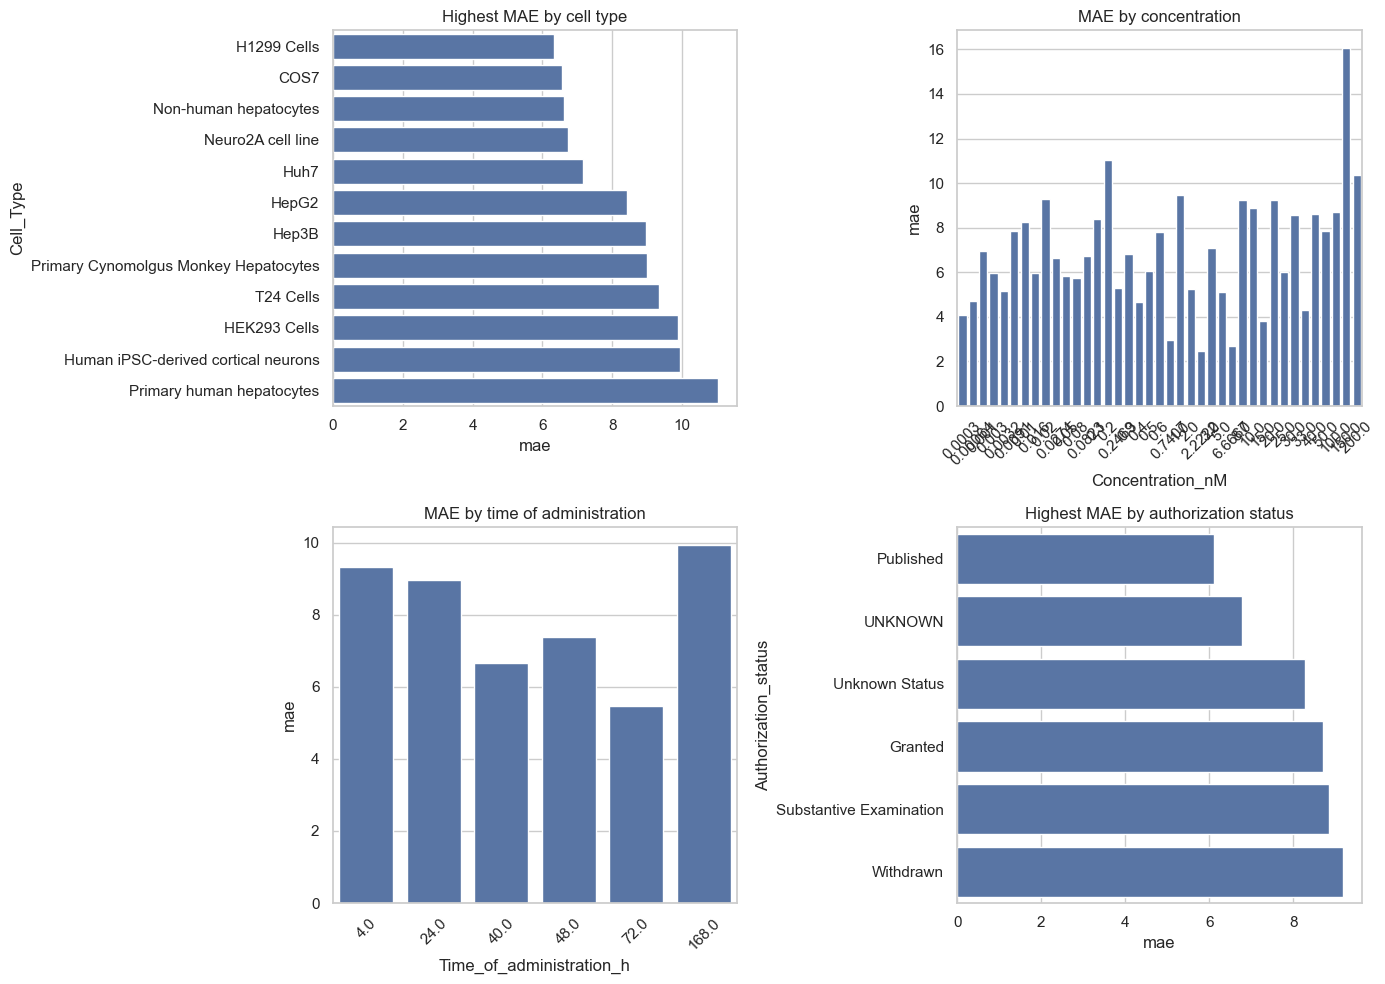

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_cell = issue_by_cell_type.head(min(12, len(issue_by_cell_type))).sort_values("mae", ascending=True)
sns.barplot(data=plot_cell, x="mae", y="Cell_Type", ax=axes[0, 0])
axes[0, 0].set_title("Highest MAE by cell type")

plot_conc = issue_by_concentration.sort_values("Concentration_nM").copy()
sns.barplot(data=plot_conc, x="Concentration_nM", y="mae", ax=axes[0, 1])
axes[0, 1].set_title("MAE by concentration")
axes[0, 1].tick_params(axis="x", rotation=45)

plot_time = issue_by_time.sort_values("Time_of_administration_h").copy()
sns.barplot(data=plot_time, x="Time_of_administration_h", y="mae", ax=axes[1, 0])
axes[1, 0].set_title("MAE by time of administration")
axes[1, 0].tick_params(axis="x", rotation=45)

plot_auth = issue_by_authorization.head(min(10, len(issue_by_authorization))).sort_values("mae", ascending=True)
sns.barplot(data=plot_auth, x="mae", y="Authorization_status", ax=axes[1, 1])
axes[1, 1].set_title("Highest MAE by authorization status")

plt.tight_layout()

## Interpretation Notes

- These results use all available data and are therefore exploratory rather than unbiased. They are for diagnosing suspicious subsets, not for claiming final model quality.
- The very high all-data Pearson/Spearman values mainly show that the model can fit the training distribution well. They should not be interpreted as true generalization performance.
- If a subset looks poor both here and in the final outer-test notebook, that is a much stronger sign that it may be poisoning training rather than merely being unlucky in one split.
- Concentration is one of the clearest issue axes. In the final outer test notebook, `0.1 nM`, `0.5 nM`, and `1 nM` behave poorly, and that makes low-dose regimes the first place to investigate for weak signal or noisy labels.
- If `Concentration + Gene` looks much worse than concentration alone, the problem is likely target-specific biology or annotation mismatch rather than only dose. In earlier results, `CTNNB1` and `PNPLA3` repeatedly looked difficult and deserve manual review.
- If `Concentration + Patent` looks much worse than concentration alone, that points to protocol or patent-source heterogeneity. From the final-test notebook, `WO2023003995A8`, `US20220117999A1`, and `WO2023034937A1` are especially worth reviewing.
- Cell-type issue summaries are useful for spotting domain shift. In the final-test notebook, `Primary mouse hepatocytes`, `Primary Cynomolgus Monkey Hepatocytes`, `COS7`, and `Hep3B` looked especially error-prone and should be treated as high-priority review contexts.
- Do not remove groups just because subgroup Spearman is below a single threshold like `0.5`. Small or biologically hard groups can have low Spearman without being bad data.
- A better removal/flagging rule before CNN training is: large enough sample count, low Spearman, high MAE, and consistency across multiple views such as concentration, patent, cell type, and final outer-test behavior.
- One more targeted investigation is still worth doing before deletion: check whether the flagged subsets also show duplicate or near-duplicate examples with inconsistent inhibition values, or unusually broad label variance within the same experimental condition.

## Within-Group Label Inconsistency And Poisoning-Risk Review

These checks look for subsets that are not only hard for the RF model, but also internally noisy. A subgroup is more suspicious if it has enough samples, weak ranking, high average error, and high label spread within the same experimental grouping.

In [16]:
def label_inconsistency_summary(df, group_cols, min_samples=20):
    rows = []
    for keys, group_df in df.groupby(group_cols, dropna=False):
        if len(group_df) < min_samples:
            continue
        corr = spearmanr(group_df["y_true"], group_df["y_pred"], nan_policy="omit").statistic
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: value for col, value in zip(group_cols, keys)}
        row.update({
            "n_samples": len(group_df),
            "label_std": float(group_df["y_true"].std(ddof=0)),
            "label_iqr": float(group_df["y_true"].quantile(0.75) - group_df["y_true"].quantile(0.25)),
            "mae": float(group_df["abs_error"].mean()),
            "rmse": float(np.sqrt(np.mean(np.square(group_df["residual"])))),
            "spearman": float(corr) if not pd.isna(corr) else np.nan,
            "mean_true": float(group_df["y_true"].mean()),
            "mean_pred": float(group_df["y_pred"].mean()),
            "mean_shift": float(abs(group_df["y_true"].mean() - group_df["y_pred"].mean())),
        })
        rows.append(row)
    return pd.DataFrame(rows)

inconsistency_concentration_gene = label_inconsistency_summary(all_predictions, ["Concentration_nM", "group"], min_samples=20)
inconsistency_concentration_patent = label_inconsistency_summary(all_predictions, ["Concentration_nM", "patent_group"], min_samples=20)
inconsistency_concentration_cell = label_inconsistency_summary(all_predictions, ["Concentration_nM", "Cell_Type"], min_samples=20)

inconsistency_concentration_gene.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,group,n_samples,label_std,label_iqr,mae,rmse,spearman,mean_true,mean_pred,mean_shift
33,0.2,AGT,75,40.902811,67.855000,11.596153,15.941869,0.951891,32.660533,36.006445,3.345912
101,50.0,MARC1,352,40.282512,55.175000,13.608595,17.439235,0.962266,47.527841,46.695564,0.832276
67,10.0,ANGPTL3,431,37.639045,72.000000,9.246983,11.520768,0.944582,55.295592,53.992336,1.303256
22,0.1,AGT,1344,35.274849,61.682500,11.715503,15.374373,0.955259,52.614360,46.953952,5.660408
95,50.0,FIREFLY LUC,37,34.159308,64.540000,9.182841,10.787113,0.972973,63.898108,64.945721,1.047613
73,10.0,LPA,60,34.000160,22.545000,12.891798,17.767989,0.866158,69.283833,67.611039,1.672794
130,100.0,GAPDH,20,33.959147,50.510354,12.473688,15.544707,0.951808,62.592014,64.731683,2.139669
76,10.0,PCSK9,863,33.944714,62.900000,8.694639,10.916701,0.963270,44.765875,44.736589,0.029286
140,200.0,MAPT,123,33.605045,65.750000,11.621683,15.158325,0.882324,64.818699,59.533065,5.285634
87,30.0,PCSK9,649,32.564218,51.000000,8.115351,10.810981,0.971203,48.479199,48.752364,0.273165


In [18]:
inconsistency_concentration_patent.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,patent_group,n_samples,label_std,label_iqr,mae,rmse,spearman,mean_true,mean_pred,mean_shift
73,1.0,CN117448322A,20,49.119956,36.40000,9.950755,15.868017,0.868322,47.430000,50.745958,3.315958
54,0.2,WO2023088227A1,75,40.902811,67.85500,11.596153,15.941869,0.951891,32.660533,36.006445,3.345912
142,50.0,US20230183707A1,352,40.282512,55.17500,13.608595,17.439235,0.962266,47.527841,46.695564,0.832276
43,0.1,WO2022121959A1,52,39.789620,35.00000,18.736158,22.887601,0.922913,64.509231,57.871877,6.637354
36,0.1,CN117448322A,66,37.813213,37.02500,17.960937,25.248166,0.750347,51.924242,47.921987,4.002255
111,10.0,US20220117999A1,337,37.685954,54.52000,13.605787,17.958293,0.943540,25.612404,29.194887,3.582484
98,10.0,CN103890000B,429,37.676672,72.00000,9.233999,11.511275,0.945397,55.226107,53.944297,1.281810
115,10.0,WO2022121959A1,48,36.803992,26.62250,15.117359,19.727320,0.886512,65.495208,64.401604,1.093604
38,0.1,US20220117999A1,339,34.260091,46.25500,11.513508,15.421803,0.955492,6.548909,8.190895,1.641986
99,10.0,CN106574268B,220,33.617261,63.67500,8.846650,11.148034,0.958890,50.421864,50.442612,0.020749


In [19]:
inconsistency_concentration_cell.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,Cell_Type,n_samples,label_std,label_iqr,mae,rmse,spearman,mean_true,mean_pred,mean_shift
72,10.0,Primary mouse hepatocytes,227,47.772123,79.2850,14.947705,18.612046,0.934620,53.783128,52.001647,1.781481
30,0.2,Hep3B,116,41.735865,72.9775,11.234334,15.344332,0.935584,16.199483,19.749683,3.550200
51,2.0,Hep3B,105,39.502412,69.9100,6.409686,9.406797,0.979625,43.678857,44.758522,1.079664
29,0.1,Primary mouse hepatocytes,227,39.252952,59.4350,12.129820,15.719705,0.967299,13.843436,14.389152,0.545716
24,0.1,Hep3B,3243,37.641734,63.7000,9.801272,13.037362,0.957120,30.284132,30.551801,0.267669
44,1.0,Hep3B,3026,34.721368,58.3425,9.508076,12.625605,0.955595,37.072488,37.759828,0.687339
85,50.0,HeLa Cells,37,34.159308,64.5400,9.182841,10.787113,0.972973,63.898108,64.945721,1.047613
25,0.1,Huh7,402,33.809487,61.0025,7.601840,10.675708,0.970370,40.777985,39.648775,1.129210
100,200.0,Human iPSC-derived cortical neurons,123,33.605045,65.7500,11.621683,15.158325,0.882324,64.818699,59.533065,5.285634
95,100.0,Primary Cynomolgus Monkey Hepatocytes,270,33.356727,60.3650,8.445622,10.557600,0.949311,39.924667,36.126181,3.798485


In [20]:
def add_risk_flags(df):
    df = df.copy()
    df["flag_low_spearman"] = df["spearman"] < 0.2
    df["flag_high_mae"] = df["mae"] > df["mae"].quantile(0.75)
    df["flag_high_label_std"] = df["label_std"] > df["label_std"].quantile(0.75)
    df["flag_high_shift"] = df["mean_shift"] > df["mean_shift"].quantile(0.75)
    df["risk_score"] = (
        df["flag_low_spearman"].astype(int)
        + df["flag_high_mae"].astype(int)
        + df["flag_high_label_std"].astype(int)
        + df["flag_high_shift"].astype(int)
    )
    return df.sort_values(["risk_score", "mae", "label_std"], ascending=[False, False, False]).reset_index(drop=True)

gene_risk = add_risk_flags(inconsistency_concentration_gene)
patent_risk = add_risk_flags(inconsistency_concentration_patent)
cell_risk = add_risk_flags(inconsistency_concentration_cell)

gene_risk.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,group,n_samples,label_std,label_iqr,mae,rmse,spearman,mean_true,mean_pred,mean_shift,flag_low_spearman,flag_high_mae,flag_high_label_std,flag_high_shift,risk_score
0,100.00,SEAP,21,31.314764,59.004817,13.508696,17.440983,0.952907,47.051758,55.621215,8.569457,False,True,True,True,3
1,1.00,INHBE,1215,29.151300,38.860000,12.550049,17.269826,0.836785,19.193424,23.450796,4.257373,False,True,True,True,3
2,0.01,AGT,70,29.756801,43.100000,12.226165,15.413403,0.896043,33.810000,39.767923,5.957923,False,True,True,True,3
3,1.00,AGT,794,30.411263,50.000000,11.899649,15.057602,0.904675,62.416234,54.932264,7.483970,False,True,True,True,3
4,0.10,AGT,1344,35.274849,61.682500,11.715503,15.374373,0.955259,52.614360,46.953952,5.660408,False,True,True,True,3
5,200.00,MAPT,123,33.605045,65.750000,11.621683,15.158325,0.882324,64.818699,59.533065,5.285634,False,True,True,True,3
6,0.20,AGT,75,40.902811,67.855000,11.596153,15.941869,0.951891,32.660533,36.006445,3.345912,False,True,True,True,3
7,10.00,AGT,1497,28.512846,41.000000,9.240277,11.215089,0.905123,71.525798,66.635023,4.890775,False,True,True,True,3
8,10.00,MARC1,45,23.442413,25.900000,13.895664,15.015003,0.942521,75.975556,64.611359,11.364197,False,True,False,True,2
9,50.00,MARC1,352,40.282512,55.175000,13.608595,17.439235,0.962266,47.527841,46.695564,0.832276,False,True,True,False,2


In [21]:
patent_risk.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,patent_group,n_samples,label_std,label_iqr,mae,rmse,spearman,mean_true,mean_pred,mean_shift,flag_low_spearman,flag_high_mae,flag_high_label_std,flag_high_shift,risk_score
0,0.10,WO2022121959A1,52,39.789620,35.0000,18.736158,22.887601,0.922913,64.509231,57.871877,6.637354,False,True,True,True,3
1,0.10,CN117448322A,66,37.813213,37.0250,17.960937,25.248166,0.750347,51.924242,47.921987,4.002255,False,True,True,True,3
2,0.01,CN117448322A,46,29.864914,36.5500,13.841467,17.474389,0.816850,34.467391,40.513109,6.045717,False,True,True,True,3
3,10.00,US20220117999A1,337,37.685954,54.5200,13.605787,17.958293,0.943540,25.612404,29.194887,3.582484,False,True,True,True,3
4,0.10,WO2023014765A1,698,32.351390,55.7500,13.047034,16.395919,0.940565,48.565903,41.080005,7.485897,False,True,True,True,3
5,1.00,WO2023003922A1,1215,29.151300,38.8600,12.550049,17.269826,0.836785,19.193424,23.450796,4.257373,False,True,True,True,3
6,1.00,WO2023014765A1,698,29.863488,51.7500,12.310659,15.357509,0.914573,62.597421,54.240129,8.357293,False,True,True,True,3
7,200.00,WO2023175091A2,123,33.605045,65.7500,11.621683,15.158325,0.882324,64.818699,59.533065,5.285634,False,True,True,True,3
8,10.00,WO2023014765A1,698,28.394465,44.7500,11.097707,12.567548,0.933004,74.248467,66.511812,7.736655,False,True,True,True,3
9,10.00,WO2022121959A1,48,36.803992,26.6225,15.117359,19.727320,0.886512,65.495208,64.401604,1.093604,False,True,True,False,2


In [22]:
cell_risk.sort_values(["spearman", "mae"], ascending=[True, False]).head(20)

,Concentration_nM,Cell_Type,n_samples,label_std,label_iqr,mae,rmse,spearman,mean_true,mean_pred,mean_shift,flag_low_spearman,flag_high_mae,flag_high_label_std,flag_high_shift,risk_score
0,0.01,Hep3B,69,29.935662,44.0000,12.211159,15.442385,0.897814,33.985507,39.837580,5.852073,False,True,True,True,3
1,200.00,Human iPSC-derived cortical neurons,123,33.605045,65.7500,11.621683,15.158325,0.882324,64.818699,59.533065,5.285634,False,True,True,True,3
2,0.20,Hep3B,116,41.735865,72.9775,11.234334,15.344332,0.935584,16.199483,19.749683,3.550200,False,True,True,True,3
3,30.00,HepG2,259,31.950473,49.5000,9.644490,13.162269,0.961921,26.741313,30.872588,4.131275,False,True,True,True,3
4,10.00,Primary human hepatocytes,414,30.669991,47.3600,15.913490,21.024920,0.734447,60.311860,60.571664,0.259804,False,True,True,False,2
5,10.00,Primary mouse hepatocytes,227,47.772123,79.2850,14.947705,18.612046,0.934620,53.783128,52.001647,1.781481,False,True,True,False,2
6,20.00,Hela,191,30.798445,55.0000,12.478345,13.967219,0.969798,41.178010,42.916131,1.738120,False,True,True,False,2
7,0.10,Primary mouse hepatocytes,227,39.252952,59.4350,12.129820,15.719705,0.967299,13.843436,14.389152,0.545716,False,True,True,False,2
8,0.10,HEK293A,20,22.789733,8.7500,11.812928,12.805733,0.731102,80.141000,69.798380,10.342620,False,True,False,True,2
9,50.00,Primary human hepatocytes,429,24.075175,33.1000,10.876718,14.355062,0.828411,45.474965,47.919031,2.444066,False,True,False,True,2


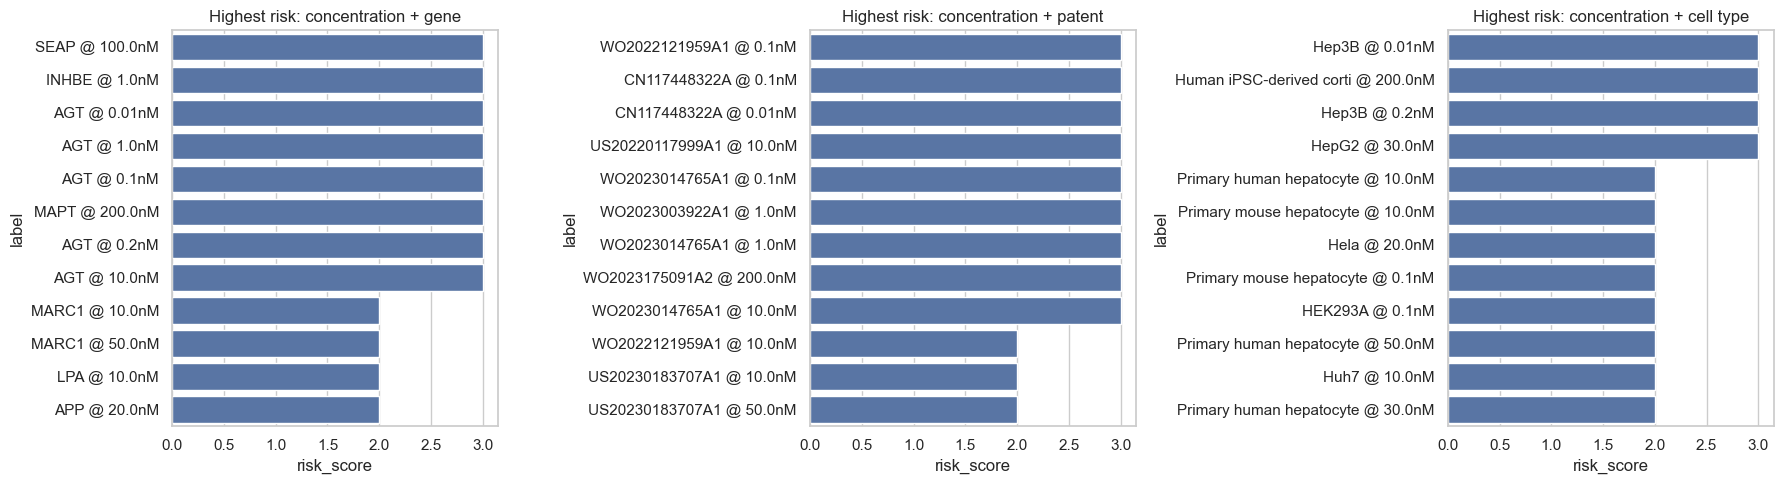

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_gene = gene_risk.head(min(12, len(gene_risk))).copy()
plot_gene["label"] = plot_gene["group"] + " @ " + plot_gene["Concentration_nM"].astype(str) + "nM"
sns.barplot(data=plot_gene, x="risk_score", y="label", ax=axes[0])
axes[0].set_title("Highest risk: concentration + gene")

plot_patent = patent_risk.head(min(12, len(patent_risk))).copy()
plot_patent["label"] = plot_patent["patent_group"].astype(str).str.slice(0, 18) + " @ " + plot_patent["Concentration_nM"].astype(str) + "nM"
sns.barplot(data=plot_patent, x="risk_score", y="label", ax=axes[1])
axes[1].set_title("Highest risk: concentration + patent")

plot_cell = cell_risk.head(min(12, len(cell_risk))).copy()
plot_cell["label"] = plot_cell["Cell_Type"].astype(str).str.slice(0, 24) + " @ " + plot_cell["Concentration_nM"].astype(str) + "nM"
sns.barplot(data=plot_cell, x="risk_score", y="label", ax=axes[2])
axes[2].set_title("Highest risk: concentration + cell type")

plt.tight_layout()

## Final Interpretation Across Both Notebooks

- The strongest evidence should come from agreement between the two views:
  1. the final outer-test notebook, which tells us where the model truly generalizes poorly, and
  2. this all-data notebook, which tells us where the subsets also look internally noisy or structurally inconsistent.
- Based on the concentration-only analysis, the clearest *review / possible removal* candidates before CNN training are the very low-dose regimes, especially `0.1 nM`, `0.5 nM`, and `1 nM`. These concentrations looked weak in the final outer-test notebook and repeatedly behaved poorly in the concentration-slice analyses.
- The combination analyses are especially important here because they tell us whether the problem is just dose or dose plus another context.
- From the `Concentration + Gene` view, the most suspicious combinations are the low-dose `CTNNB1` slices and the `PNPLA3` low-dose / moderate-dose slices that repeatedly showed weak ranking or large error. Those combinations suggest the issue is not only concentration, but concentration interacting with specific target biology.
- From the `Concentration + Patent` view, the most suspicious combinations are low-dose and moderate-dose slices inside `WO2023003995A8`, `US20220117999A1`, and `WO2023034937A1`. That pattern suggests protocol or patent-source heterogeneity on top of the concentration effect, rather than a purely global dose problem.
- The clearest *patent-level* review candidates in general remain `WO2023003995A8`, `US20220117999A1`, and `WO2023034937A1`, because they were weak on the final outer-test notebook and also remain suspicious in the all-data concentration-plus-patent and risk analyses.
- The clearest *cell-context* review candidates are `Primary mouse hepatocytes`, `Primary Cynomolgus Monkey Hepatocytes`, `Hep3B`, and `COS7`, because they showed high error or weak ranking in the final outer-test notebook and continue to appear as hard contexts in the all-data investigation.
- `Primary mouse hepatocytes` deserve especially high priority for review: on the final outer test they showed extremely poor behavior, with very high error and weak ranking, while in the all-data notebook they looked easy after training. That pattern is consistent with a context that fits in-sample but generalizes poorly, which is exactly the kind of regime that can destabilize later CNN training.
- `72h` time of administration is another strong review candidate. In the final outer-test notebook it showed high error and weak ranking, while in the all-data notebook it looked very learnable. That gap suggests a context-shift or transferability issue rather than simple random noise, and it is worth testing as an exclusion or isolation ablation before CNN training.
- The clearest *gene-level* review candidates are `PNPLA3` and `CTNNB1`, but the combination analysis makes the conclusion sharper: the concern is strongest when those genes appear inside the problematic concentration bands, not simply because the gene name appears at all.
- Some subsets show high label spread but still strong Spearman in the all-data notebook. Those should **not** be removed automatically. High variance alone does not mean poisoning if the model can still rank the examples reasonably well.
- Small groups should also be treated cautiously. A subset with only a few dozen examples can look unstable without truly poisoning the dataset.
- So the safest interpretation is: do **not** remove everything with high variance or everything with low subgroup Spearman. Instead, focus on the subsets that are repeatedly poor across both notebooks and large enough to materially affect training.
- If you want to create a filtered dataset before CNN training, the most defensible first ablation is:
  - remove or isolate the suspicious low-dose regimes (`0.1`, `0.5`, `1 nM`),
  - optionally remove or separately track the worst *combinations* first, such as low-dose `CTNNB1` / `PNPLA3` slices and low-dose or moderate-dose slices from `WO2023003995A8`, `US20220117999A1`, and `WO2023034937A1`,
  - explicitly test `Primary mouse hepatocytes` and `72h` as separate ablations, because both look easy in-sample but poor on held-out final test data,
  - only after that consider dropping whole patent groups or broader regimes,
  - then compare CNN-ready preprocessing on full vs filtered data rather than committing to permanent deletion immediately.

## Optional Export

In [15]:
processed_dir = os.environ.get("CMSIRNA_PROCESSED_DIR")
if processed_dir:
    output_dir = Path(processed_dir)
    all_data_metrics.to_csv(output_dir / "rf_all_data_metrics.csv", index=False)
    all_predictions.to_csv(output_dir / "rf_all_data_predictions.csv", index=False)
    spearman_by_concentration.to_csv(output_dir / "rf_all_data_spearman_by_concentration.csv", index=False)
    spearman_by_concentration_gene.to_csv(output_dir / "rf_all_data_spearman_by_concentration_gene.csv", index=False)
    spearman_by_concentration_patent.to_csv(output_dir / "rf_all_data_spearman_by_concentration_patent.csv", index=False)
    issue_by_cell_type.to_csv(output_dir / "rf_all_data_issue_by_cell_type.csv", index=False)
    issue_by_concentration.to_csv(output_dir / "rf_all_data_issue_by_concentration.csv", index=False)
    issue_by_time.to_csv(output_dir / "rf_all_data_issue_by_time.csv", index=False)
    issue_by_patent.to_csv(output_dir / "rf_all_data_issue_by_patent.csv", index=False)
    issue_by_authorization.to_csv(output_dir / "rf_all_data_issue_by_authorization.csv", index=False)
    inconsistency_concentration_gene.to_csv(output_dir / "rf_all_data_inconsistency_concentration_gene.csv", index=False)
    inconsistency_concentration_patent.to_csv(output_dir / "rf_all_data_inconsistency_concentration_patent.csv", index=False)
    inconsistency_concentration_cell.to_csv(output_dir / "rf_all_data_inconsistency_concentration_cell.csv", index=False)
    gene_risk.to_csv(output_dir / "rf_all_data_gene_risk.csv", index=False)
    patent_risk.to_csv(output_dir / "rf_all_data_patent_risk.csv", index=False)
    cell_risk.to_csv(output_dir / "rf_all_data_cell_risk.csv", index=False)
    print("Saved all-data investigation tables to:", output_dir)
else:
    print("CMSIRNA_PROCESSED_DIR is not set; skipping export.")

Saved all-data investigation tables to: /Users/yesminemaalej/siRNA-Pharmaceutical-Modeling-with-Foundation-Models/data/processed
